In [1]:
import numpy as np
import scipy.constants as const
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
import seaborn as sns

colors = sns.color_palette("tab10")
e = const.elementary_charge  # Elementary charge in Coulombs
mass_u = const.physical_constants['atomic mass constant'][0]  # Atomic mass unit in kg
hbar = const.hbar  # Reduced Planck's constant in J·s
angstrom = 1e-10  # 1 Angstrom in meters
 
# read data from file
data = np.loadtxt('potential_data', skiprows=1)
x_data = data[:, 0]  # x values in Angstroms
E_data = data[:, 1]  # Energy values in eV

E_shifted = E_data - E_data.min()  # Shift energies so that minimum is at 0 eV

# Preprocessing

### Fits

In [2]:
# --- Quadratic model ---
def quadratic_model(x, a, b, c):
    return a + b * (x - c)**2
guess_quadratic = [0.0, 100.0, 0.0]  # [offset, curvature, center]


# --- Polynomial model (cubic) ---
def polynomial_model(x, a3, a2, a1, a0):
    return a3 * x**3 + a2 * x**2 + a1 * x + a0
guess_polynomial = [0.0, 0.0, -1.0, 1000.0]  # [a3, a2, a1, a0]


# --- Morse potential model ---
def morse_model(x, D_e, a, r_e, offset):
    return D_e * (1 - np.exp(-a * (x - r_e)))**2 + offset
guess_morse = [E_shifted.max() - E_shifted.min(), 1.0, x_data.mean(), E_shifted.min()]  # Initial guess for [D_e, a, r_e, offset]


In [3]:
def fit_model(x, model, guess):
    popt, pcov = curve_fit(model, x, E_shifted, p0=guess)
    return popt, pcov

params_quadratic, _ = fit_model(x_data, quadratic_model, guess_quadratic)
params_polynomial, _ = fit_model(x_data, polynomial_model, guess_polynomial)
params_morse, _ = fit_model(x_data, morse_model, guess_morse)

c:\Users\Francesco\AppData\Local\Anaconda\Lib\site-packages\scipy\optimize\_minpack_py.py:1010: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',


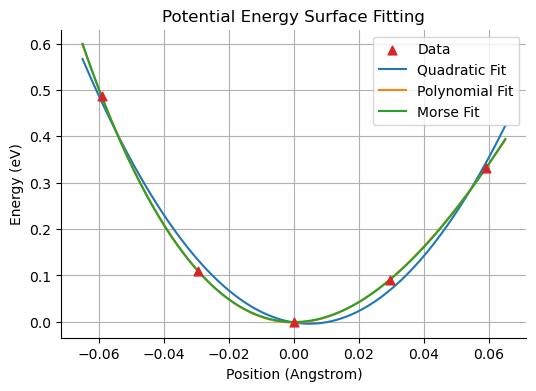

In [4]:
X_axis = np.linspace(x_data.min()*1.1, x_data.max()*1.1, 200)

plt.figure(figsize=(6, 4))
plt.scatter(x_data, E_shifted, label='Data', marker='^', color=colors[3], s=40, zorder = 5)
plt.plot(X_axis, quadratic_model(X_axis, *params_quadratic), label='Quadratic Fit', color=colors[0])
plt.plot(X_axis, polynomial_model(X_axis, *params_polynomial), label='Polynomial Fit', color=colors[1])
plt.plot(X_axis, morse_model(X_axis, *params_morse), label='Morse Fit', color=colors[2])
plt.xlabel('Position (Angstrom)')
plt.ylabel('Energy (eV)')
plt.title('Potential Energy Surface Fitting')
plt.legend()
plt.grid()
sns.despine()
plt.show()


### Verification model

In [5]:
parameter = params_quadratic[1]*e  # in J 

omega = 265.495409 *1e-3 * e / hbar  # Convert meV to J and then to angular frequency
m_eff = 13.585135873543415 * mass_u  # Effective mass in kg

factor = 0.5 * m_eff * omega**2 * (angstrom**2)  # Conversion in J

conv = factor/parameter

print("Conversion factor from eV to J: ", conv)  # in eV

Conversion factor from eV to J:  0.9798921312901426


# Solving the Schrödinger equation

### Morse potential --> Analytical solution
Eigenenergies: $\epsilon_n/D_e = (2 \lambda -n - \frac{1}{2})(n + \frac{1}{2})$

In [ ]:
# convert in SI units for further calculations
D_e = params_morse[0] * e  # in J
a = params_morse[1] / angstrom  # in 1/m
r_e = params_morse[2] * angstrom  # in m
offset = params_morse[3] * e  # in J

# Solving the Schrödinger equation
lambda_param = np.sqrt(2 * m_eff * D_e) / (a * hbar) # see parametrization wikipedia
n_max = int(2 * lambda_param - 0.5)
energy_levels = []
for n in range(10):
    epsilon_n = (2 * lambda_param - n - 0.5) * (n + 0.5) * (hbar * a)**2 / (2 * m_eff)
    energy_levels.append(epsilon_n + offset)

print("Calculated energy levels (in eV):")
for i, energy in enumerate(energy_levels):
    print(f"n={i}: {energy / e:.4f} eV")

Calculated energy levels (in eV):
n=0: 0.1319 eV
n=1: 0.3938 eV
n=2: 0.6525 eV
n=3: 0.9081 eV
n=4: 1.1605 eV
n=5: 1.4097 eV
n=6: 1.6557 eV
n=7: 1.8986 eV
n=8: 2.1382 eV
n=9: 2.3747 eV


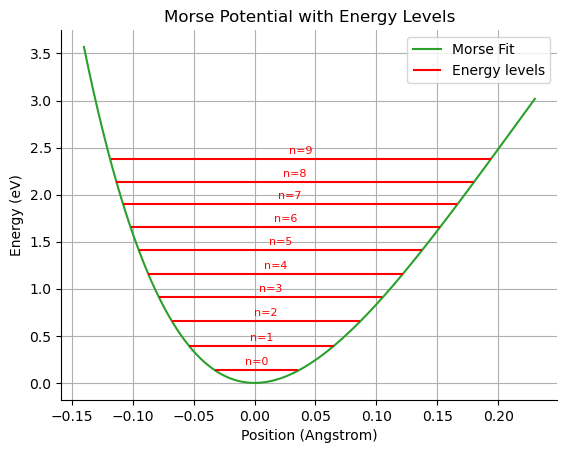

In [10]:
x_vals = np.linspace(-0.14, 0.23, 1000)

plt.plot(x_vals, morse_model(x_vals, *params_morse), label='Morse Fit', color=colors[2])
for n, energy in enumerate(energy_levels):
    min_index = np.where(morse_model(x_vals, *params_morse) <= energy / e)[0][0]
    max_index = np.where(morse_model(x_vals, *params_morse) <= energy / e)[0][-1]
    xi, xj = x_vals[min_index], x_vals[max_index]
    plt.hlines(energy / e, xi, xj, colors='r', label='Energy levels' if n == 0 else "")
    # place level label centered above the line
    xmid = 0.5 * (xi + xj)
    vp = morse_model(x_vals, *params_morse)
    y_offset = 0.01 * (vp.max() - vp.min())
    plt.text(xmid, energy / e + y_offset, f"n={n}", ha='center', va='bottom', color='r', fontsize=8)
    
plt.xlabel('Position (Angstrom)')
plt.ylabel('Energy (eV)')
plt.title('Morse Potential with Energy Levels')
plt.legend()
sns.despine()
plt.grid()

### Numerical solution 